[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# Laboratorio 1ra Parte: Optimización y Validación de Clústeres con K-Means

### Estudiante: Delgado Ramos Jorge Luis

## 1. Introducción y Objetivo

En el aprendizaje no supervisado, uno de los desafíos principales es determinar si el agrupamiento realizado por el algoritmo es coherente con la naturaleza de los datos. El objetivo de este ejercicio es modificar un generador de datos sintéticos para crear escenarios complejos (con hasta 20 grupos) y aplicar métricas de validación que nos permitan encontrar el número óptimo de clústeres de forma científica, más allá de la simple inspección visual.

## 2. Generación Dinámica de Datos Sintéticos
Para esta práctica, se ha modificado el generador de datos para que sea altamente flexible y dinámico. Las características de esta nueva implementación son:Cantidad Aleatoria de Centroides: El algoritmo genera un número de centros ($k$) seleccionado al azar en un rango de 1 a 20.  Separación Espacial Garantizada: Para permitir una verificación visual clara una vez realizado el entrenamiento, los centros se distribuyen en un espacio amplio (coordenadas entre -10 y 10), evitando que los grupos se solapen excesivamente de forma automática.  Variabilidad en la Dispersión: Cada grupo recibe una desviación estándar (cluster_std) aleatoria, lo que significa que algunos grupos estarán muy compactos y otros más dispersos, simulando datos reales más heterogéneos.

In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import random

# Definir la cantidad aleatoria de centroides (entre 1 y 20)
num_centroides = random.randint(1, 20)
print(f"Cantidad de centroides generados aleatoriamente: {num_centroides}")

# Generar centros aleatorios con una separación importante para verificación visual
# Rango de coordenadas X e Y entre -10 y 10
blob_centers = np.random.uniform(low=-10.0, high=10.0, size=(num_centroides, 2))

# Generar una desviación estándar aleatoria para cada cluster (entre 0.5 y 1.5)
blob_std = np.random.uniform(low=0.5, high=1.5, size=num_centroides)

# Generar el dataset sintético
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

Cantidad de centroides generados aleatoriamente: 10


In [3]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

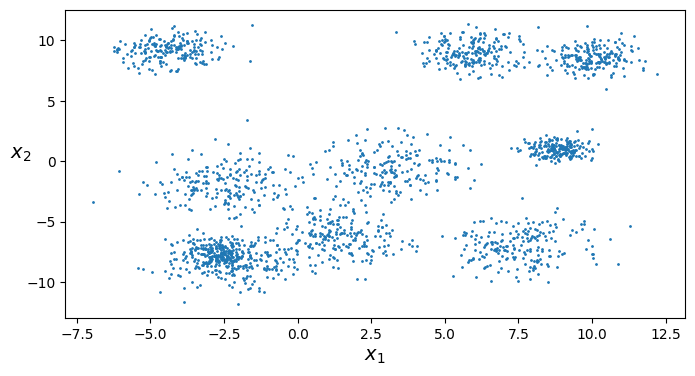

In [4]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [5]:
from sklearn.cluster import KMeans

k = 9
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([6, 6, 3, ..., 6, 6, 1], dtype=int32)

In [6]:
kmeans.cluster_centers_

array([[ 3.16486832, -0.55550868],
       [10.01010644,  8.55655081],
       [-2.46521339, -1.87815408],
       [ 1.43465332, -6.25796669],
       [-4.34801725,  9.20815106],
       [ 8.8080058 ,  0.98611834],
       [-2.45808215, -8.0078815 ],
       [ 7.54722439, -6.985437  ],
       [ 5.88715536,  9.02452492]])

In [7]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 0, 2, 2], dtype=int32)

In [8]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

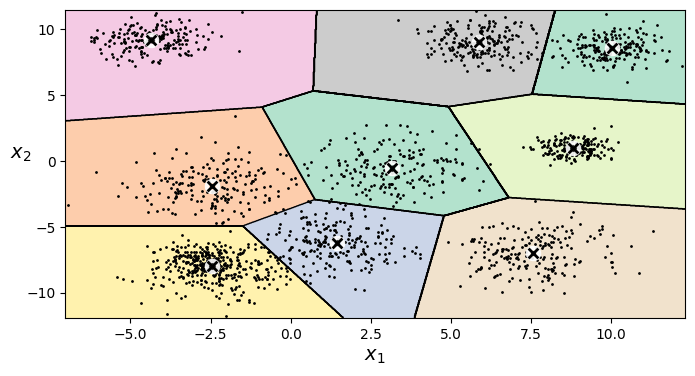

In [9]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

In [10]:
kmeans.transform(X_new)

array([[ 4.06780237, 11.96622704,  4.59536246,  8.38166117,  8.41799832,
         8.86616727, 10.30533163, 11.73450783,  9.16529043],
       [ 2.56082139,  9.59843481,  6.70139064,  8.40501779, 10.29324046,
         5.89583644, 11.39948915, 10.07051775,  7.59470976],
       [ 7.11668767, 14.14701829,  4.90738056, 10.26528603,  6.3528175 ,
        11.97851077, 11.02121273, 14.52421752, 10.73668622],
       [ 6.88053302, 14.35077271,  4.41069494,  9.81672708,  6.8422541 ,
        11.90465617, 10.52184625, 14.18511394, 11.025015  ]])

In [13]:
kmeans_iter1 = KMeans(n_clusters=9, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=9, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

kmeans_iter3 = KMeans(n_clusters=9, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=9, n_init=1, random_state=5)

## 3. Verificación Visual: Fronteras de Decisión
La efectividad de K-Means se confirma visualmente mediante la representación de las fronteras de decisión o regiones de Voronoi. Estas regiones dividen el espacio total en función del centroide más cercano. En un modelo exitoso, la gran mayoría de los puntos de un mismo color deben quedar contenidos dentro de su respectiva región sombreada, y los centroides (marcados con una 'X') deben ubicarse en el núcleo de la densidad de puntos.

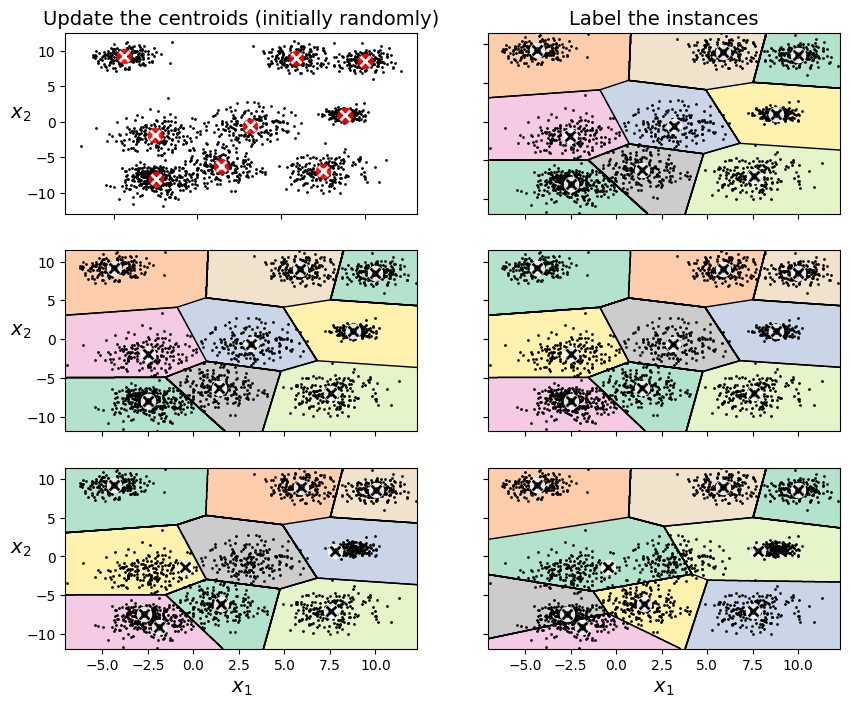

In [14]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

In [15]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

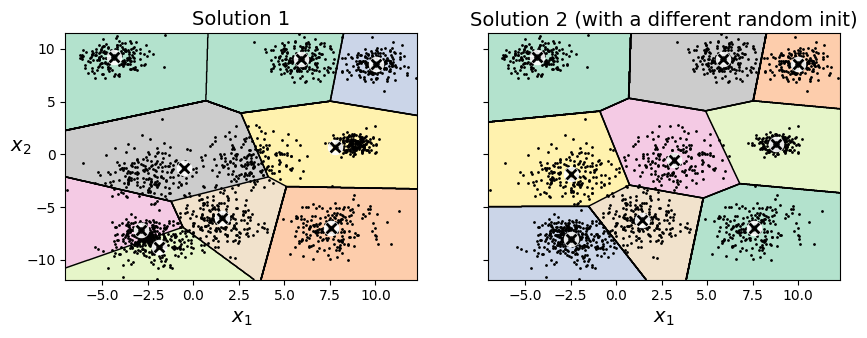

In [16]:
kmeans_rnd_init1 = KMeans(n_clusters=9, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=9, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

In [19]:
kmeans_rnd_10_inits = KMeans(n_clusters=9, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=9, n_init=10,
       random_state=11)

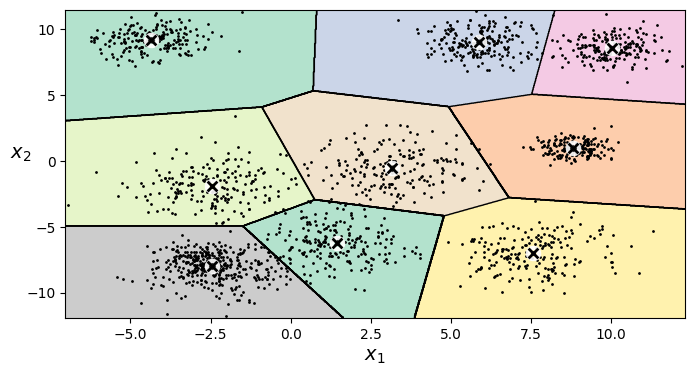

In [33]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.6376235141500369)

## 4. Métricas de Evaluación de Efectividad
Para demostrar la efectividad del modelo y la precisión en la elección de $k$, utilizaremos dos herramientas fundamentales:

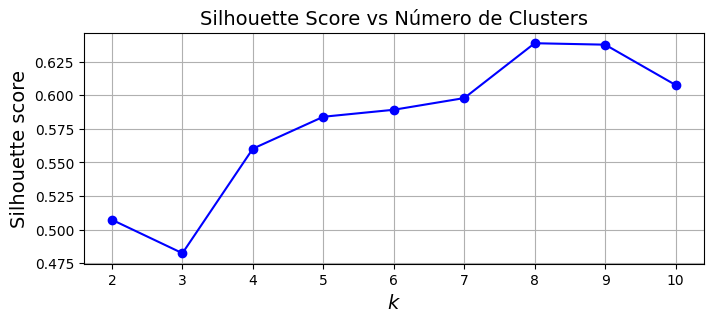

In [22]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))  # no más de los centros generados
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

# plt.figure(figsize=(8, 3))
# plt.plot(ks, silhouette_scores, "bo-")
# # plt.plot(range(2, 10), silhouette_scores, "bo-")
# plt.xlabel("$k$", fontsize=14)
# plt.ylabel("Silhouette score", fontsize=14)
# plt.axis([1.8, 8.5, 0.55, 0.7])
# plt.show()

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

###4.1 El Método del Codo
Este método utiliza la métrica de Inercia, que representa la suma de las distancias al cuadrado de las muestras a su centroide más cercano.  Lógica: A medida que $k$ aumenta, la inercia disminuye.Identificación: El valor óptimo de clústeres se encuentra en el punto donde la disminución de la inercia deja de ser abrupta y se vuelve lineal, formando un ángulo similar a un "codo".

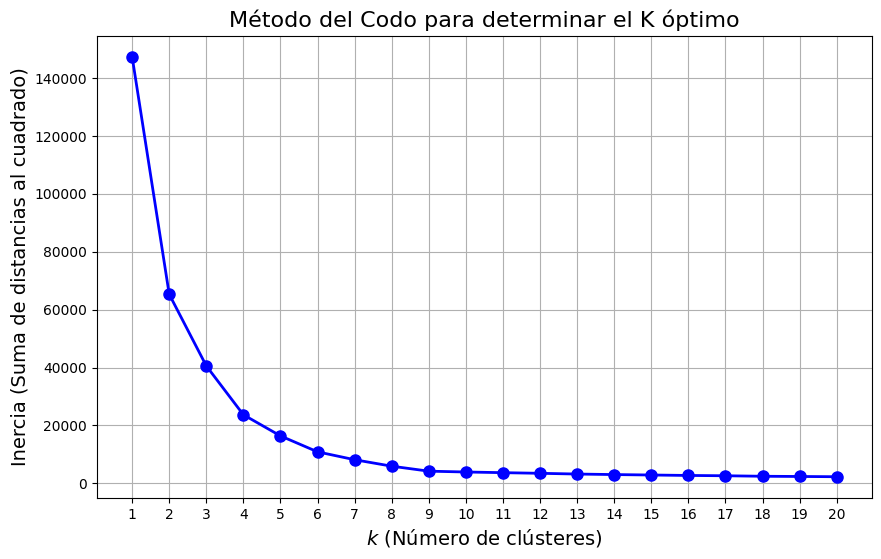

In [32]:
# IMPLEMENTACIÓN DEL MÉTODO DEL CODO

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Definir el rango de clústeres a evaluar (por ejemplo, de 1 a 20)
inercias = []
rango_k = range(1, 21)

# 2. Entrenar el modelo para cada valor de k y extraer la inercia
for k in rango_k:
    # Usamos n_init=10 para asegurar estabilidad en los resultados
    kmeans_modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_modelo.fit(X)
    inercias.append(kmeans_modelo.inertia_)

# 3. Graficar los resultados para identificar el "punto de codo"
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercias, "bo-", linewidth=2, markersize=8)

# Añadir etiquetas y formato para facilitar la verificación visual
plt.xlabel("$k$ (Número de clústeres)", fontsize=14)
plt.ylabel("Inercia (Suma de distancias al cuadrado)", fontsize=14)
plt.title("Método del Codo para determinar el K óptimo", fontsize=16)
plt.xticks(rango_k) # Asegurar que todos los números de k se vean en el eje

plt.grid(True)
plt.show()

###4.2 Coeficiente de Silueta (Silhouette Score)
A diferencia de la inercia, el coeficiente de silueta mide tanto la cohesión (qué tan cerca está un punto de su propio grupo) como la separación (qué tan lejos está de los demás grupos).  

Rango: El valor va de -1 a +1.

Interpretación: Un valor cercano a +1 indica que el punto está muy bien agrupado. Un valor cercano a 0 indica que el punto está en la frontera de dos clústeres.

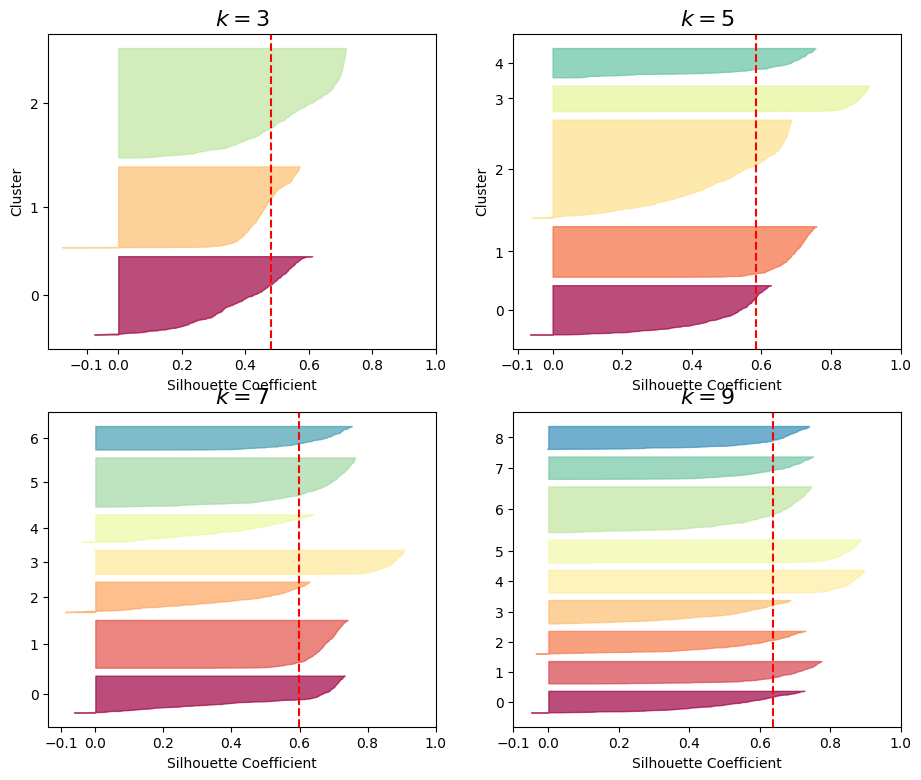

In [29]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 5, 7, 9) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (3, 5, 7, 9):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()